## Helmut Müller
# Woche 8: Data Visualization - NHANES - Depression  

# Variablen  
|Abkürzung|Beschreibung|
|:----|:----|
|SEQN |Respondent sequence number|
|RIAGENDR |Gender|
|RIDAGEYR |Age in years at screening|
|DMDEDUC2 |Education level - Adults 20+|
|DMDMARTZ |Marital status|
|BMXBMI |Body Mass Index (kg/m**2)|
|OCD150 |Type of work done last week|
|ASH |Average Sleep Hours|
|MEMPW |moderate equivalent minutes per week|
|**DEPS** |**Depression Severity**|


Im Verlauf der Analyse wurde zur Ermittlung von Anteilswerten zunehmend nur noch zwischen "keiner/leichter depressiver Symptomatik" und "behandlungsbedürftiger depressiver Symptomatik" (neue Variable: DEPT) unterschieden. Durch die binäre Kodierung konnten die Mittelwerte der jeweiligen Gruppen direkt als Anteile der behandlungsbedürftigen Fälle interpretiert werden.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup komplett")

Setup komplett


In [35]:
# Laden der bereinigten Daten aus Woche 7
df = pd.read_csv('NHANES_depression.csv')
print(f"Geladen: {df.shape}")
display(df.head())

Geladen: (5441, 29)


,SEQN,RIAGENDR,RIDAGEYR,DMDEDUC2,DMDMARTZ,BMXBMI,OCD150,SLD012,SLD013,PAD790Q,...,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,PHQ9,DEPS,ASH,MEMPW,DEPT
0,130379,1,66,5,1,33.5,1,9.0,9.0,4.0,...,0,0,0,0,0,1,0,9.000000,450.000000,0
1,130380,2,44,3,1,29.7,1,8.0,9.0,1.0,...,0,0,0,0,0,2,0,8.285714,20.000000,0
2,130386,1,34,4,1,30.2,1,7.5,8.0,1.0,...,0,1,0,0,0,1,0,7.642857,43.793103,0
3,130387,2,68,5,3,42.6,4,3.0,5.0,0.0,...,0,0,0,0,0,0,0,3.571429,0.000000,0
4,130389,1,59,5,1,28.0,1,8.0,8.0,3.0,...,0,0,0,0,0,0,0,8.000000,162.586207,0


> Ich arbeite mit dem bereinigten NHANES_depression Datensatz aus Woche 7. Der Datensatz enthält Daten von 5441 Patienten. Jede Zeile ist ein Patient mit Informationen wie Alter, Geschlecht, Familienstand und ob keine, eine leichte, oder eine mittelschwere (behandlungsbedürftgite) drepessive Sympotmatik vorliegt.

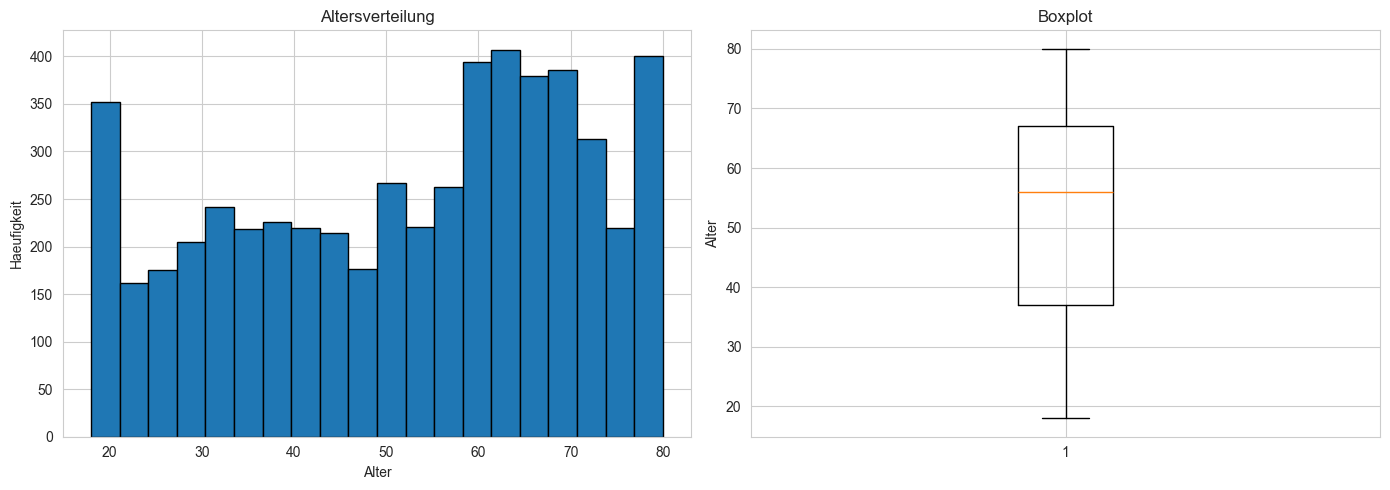

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['RIDAGEYR'], bins=20, edgecolor='black')
ax[0].set_xlabel('Alter')
ax[0].set_ylabel('Haeufigkeit')
ax[0].set_title('Altersverteilung')

ax[1].boxplot(df['RIDAGEYR'])
ax[1].set_ylabel('Alter')
ax[1].set_title('Boxplot')

plt.tight_layout()
plt.show()

In [4]:
df['RIDAGEYR'].max()

np.int64(80)

Bei der Erhebung der Daten wurden allen Probanden > 80 Jahre das alter 80 zugewiesen.
Da für das Depression Screening (Aus Jugendschutzgründen) nur Daten von erwachsenen Probanden öffenltich zugänglich sind, ist das Mindestalter hier 18 Jahre.

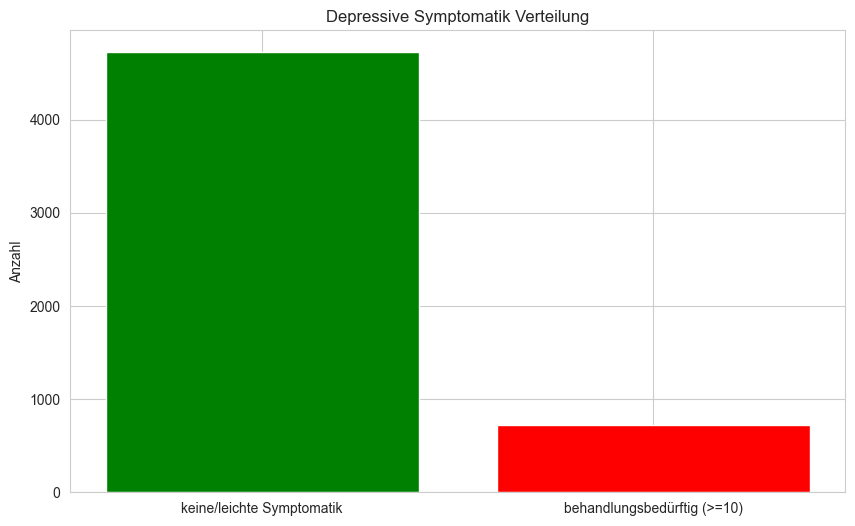

keine/leichte Symptomatik: 4724 (86.8%)
behandlungsbedürftig (>=10): 717 (13.2%)


In [38]:
counts = df['DEPT'].value_counts()
plt.bar(['keine/leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \
        counts.values, color=['green', 'red'])
plt.ylabel('Anzahl')
plt.title('Depressive Symptomatik Verteilung')
plt.show()

print(f"keine/leichte Symptomatik: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"behandlungsbedürftig (>=10): {counts[1]} ({counts[1]/len(df)*100:.1f}%)")


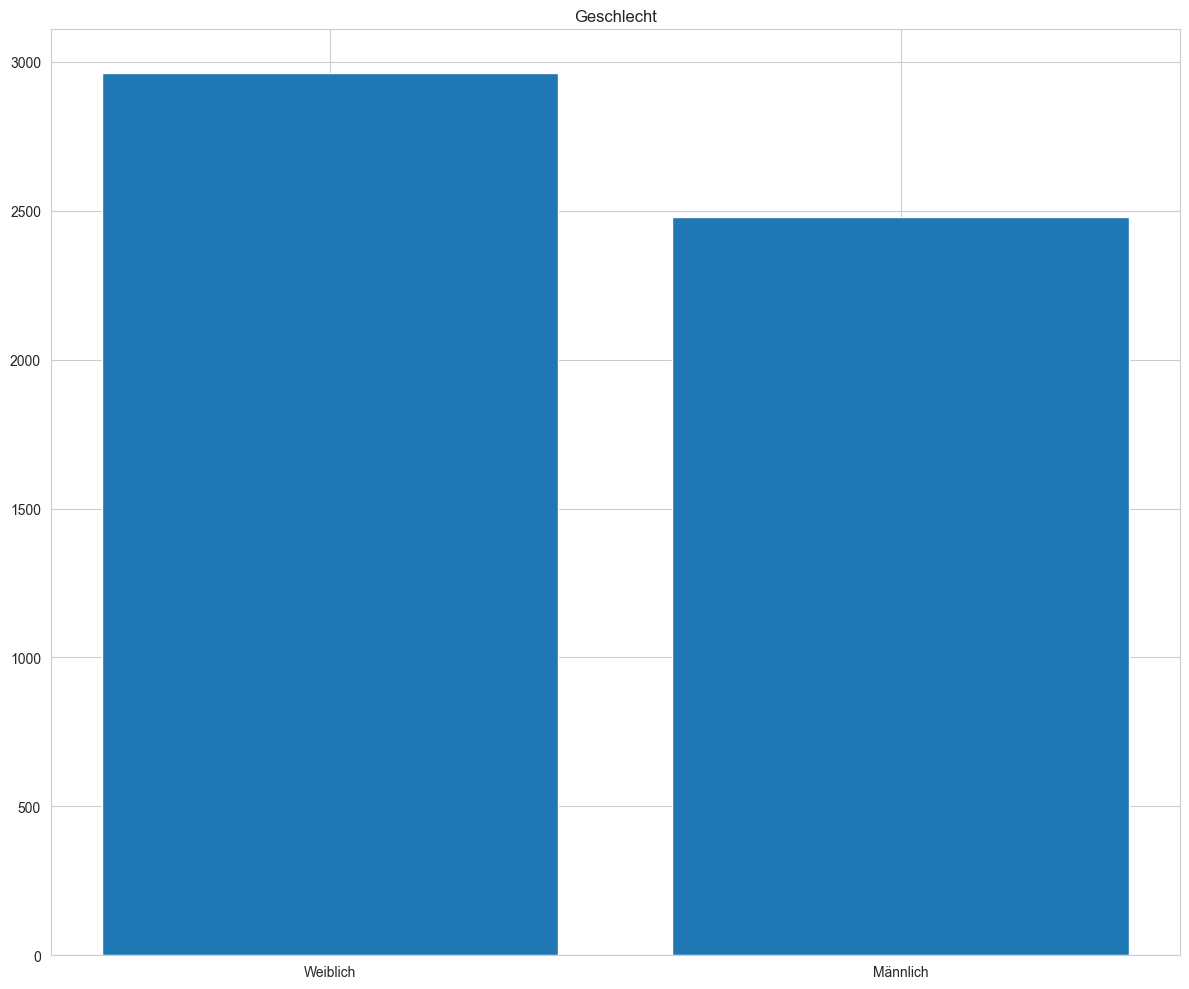

Weiblich: 2961 (54.4%)
Männlich: 2480 (45.6%)


In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

gender_map = {1: 'Männlich', 2: 'Weiblich'}
sex_counts = df['RIAGENDR'].map(gender_map).value_counts()
ax.bar(sex_counts.index, sex_counts.values)
ax.set_title('Geschlecht')


plt.tight_layout()
plt.show()

total = sex_counts.sum()

print(f"Weiblich: {sex_counts['Weiblich']} ({sex_counts['Weiblich']/total:.1%})")
print(f"Männlich: {sex_counts['Männlich']} ({sex_counts['Männlich']/total:.1%})")

wir haben mit 54.4 zu 45.6 eine relativ ausgewogene Geschlechterverteilung im Datensatz.

/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/1244101607.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \


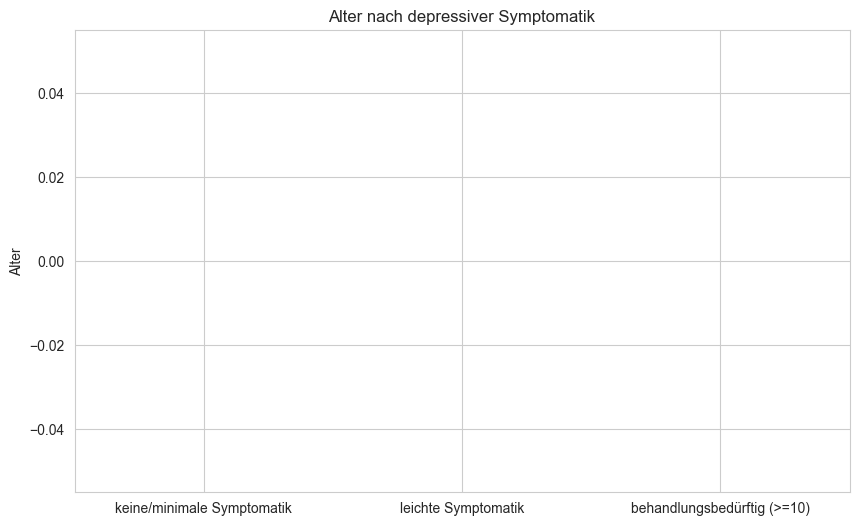

Durchschnitt keine/minimale Symptomatik: nan
Durchschnitt leichte Symptomatik: nan
Durchschnitt behandlungsbedürftig (>=10): nan


In [7]:
no_symtpoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['RIDAGEYR']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['RIDAGEYR']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['RIDAGEYR']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \
                                                                'leichte Symptomatik', 'behandlungsbedürftig (>=10)'])
plt.ylabel('Alter')
plt.title('Alter nach depressiver Symptomatik')
plt.show()

print(f"Durchschnitt keine/minimale Symptomatik: {no_symtpoms.mean():.1f}")
print(f"Durchschnitt leichte Symptomatik: {mild_symptoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")



/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/3155299850.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_or_mild_symtpoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig'])


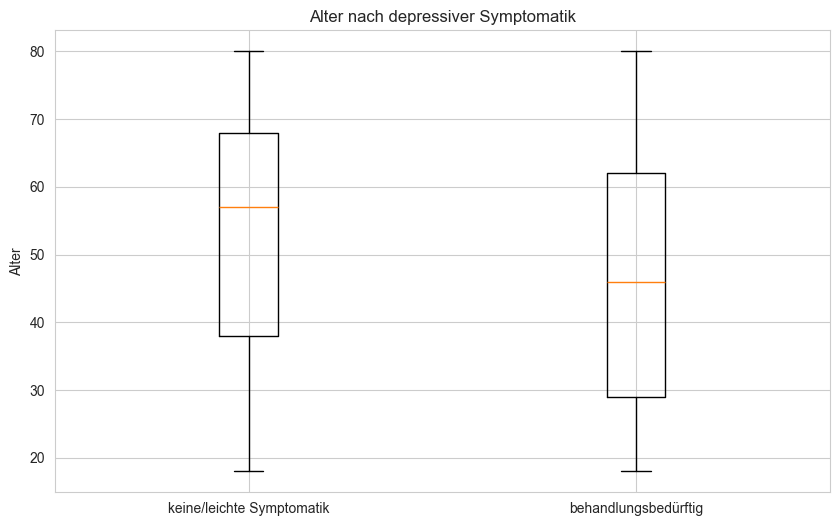

Durchschnitt keine/leichte Symptomatik: 53.1
Durchschnitt behandlungsbedürftig (>=10): 46.1


In [8]:
no_or_mild_symtpoms = df[df['DEPT'] == 0]['RIDAGEYR']
should_treat = df[df['DEPT'] == 1]['RIDAGEYR']

plt.figure(figsize=(10, 6))
plt.boxplot([no_or_mild_symtpoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig'])
plt.ylabel('Alter')
plt.title('Alter nach depressiver Symptomatik')
plt.savefig('figures/Alter_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Durchschnitt keine/leichte Symptomatik: {no_or_mild_symtpoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")






Das mittlere Alter der Probanden ist in den Gruppen mit stärkrer depressiver Symptomatik höher. Auch hier ist zu beachten, dass alle Probanden >= 20 Jahre alt sind und weiterhin alle Probanden über 80 Jahre das Alter 80 zugewiesen bekommen haben.

/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/2539867106.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symptoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \


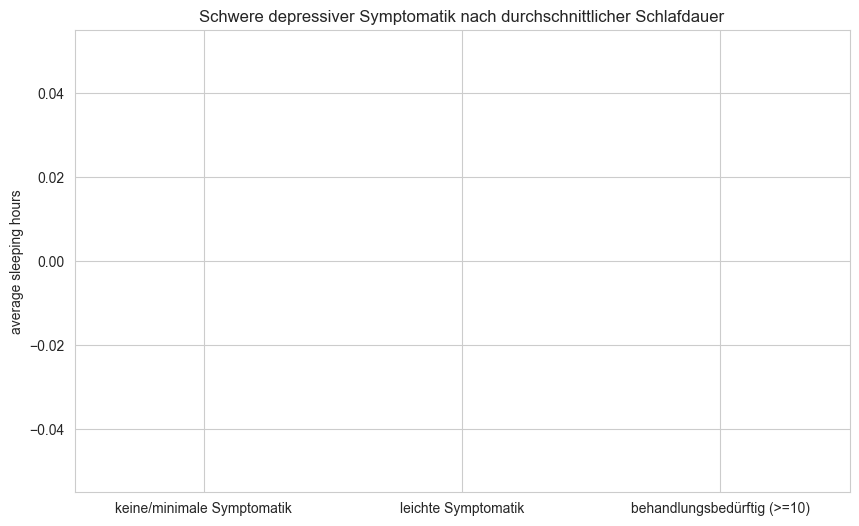

Mittlere Schlafdauer - keine/minimale Symptomatik: nan (SD: nan)
Mittlere Schlafdauer - leichte Symptomatik: nan (SD: nan)
Mittlere Schlafdauer - behandlungsbedürftig (>=10): nan (SD: nan)


In [9]:
no_symptoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['ASH']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['ASH']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['ASH']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symptoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \
                                                                'leichte Symptomatik', 'behandlungsbedürftig (>=10)'])
plt.ylabel('average sleeping hours')
plt.title('Schwere depressiver Symptomatik nach durchschnittlicher Schlafdauer')
plt.show()

print(f"Mittlere Schlafdauer - keine/minimale Symptomatik: {no_symptoms.mean():.1f} (SD: {no_symptoms.std():.1f})")
print(f"Mittlere Schlafdauer - leichte Symptomatik: {mild_symptoms.mean():.1f} (SD: {mild_symptoms.std():.1f})")
print(f"Mittlere Schlafdauer - behandlungsbedürftig (>=10): {should_treat.mean():.1f} (SD: {should_treat.std():.1f})")



Die mittlere Schlafdauer unterscheidet sich bei Probanden mit unterschiedlich starkter depressiver Symptomatik nicht. Allerdings steigt die Varianz der Shlafdauer mit zunehmender Schwere der depressiven Symptomatik. Hier schlafen Probanden also öfters besonders lang oder besonders kurz im Vergleich zu gesunden Probanden.

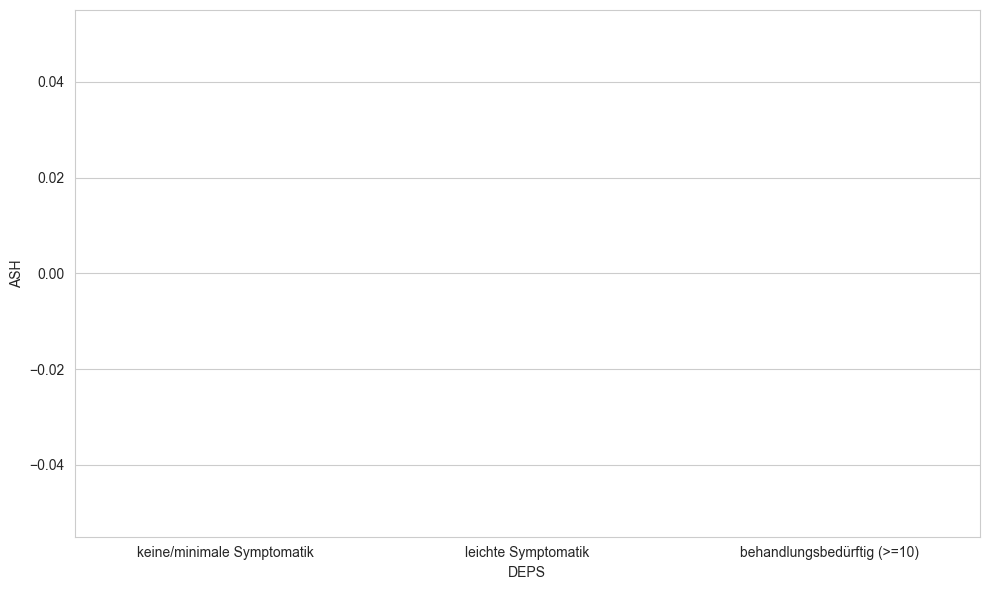

In [10]:
# Violin plot: combi --> Boxplot + KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x= 'DEPS' , y='ASH', ax=ax,  order=[
        'keine/minimale Symptomatik',
        'leichte Symptomatik',
        'behandlungsbedürftig (>=10)'
    ])
plt.tight_layout()
plt.show()

/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/809427061.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


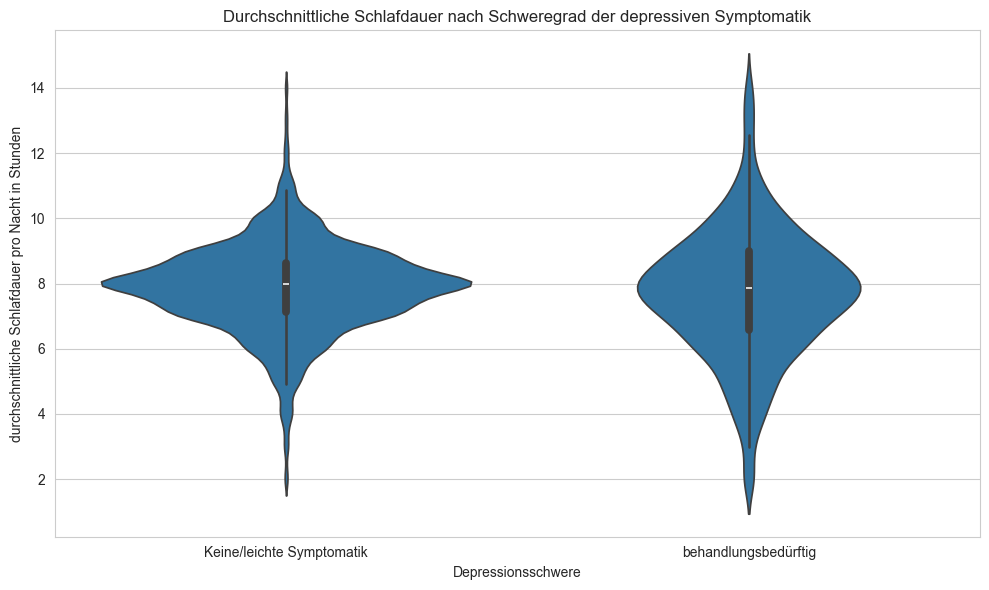

In [11]:
# Violin plot: combi --> Boxplot + KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x= 'DEPT' , y='ASH', ax=ax,  order=[
        0,
        1
    ])
ax.set_xlabel('Depressionsschwere'), 
ax.set_ylabel('durchschnittliche Schlafdauer pro Nacht in Stunden')

ax.set_xticklabels([
    'Keine/leichte Symptomatik',
    'behandlungsbedürftig'
])

ax.set_title('Durchschnittliche Schlafdauer nach Schweregrad der depressiven Symptomatik')
plt.tight_layout()
plt.savefig('figures/Schlafdauer_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/725859019.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \


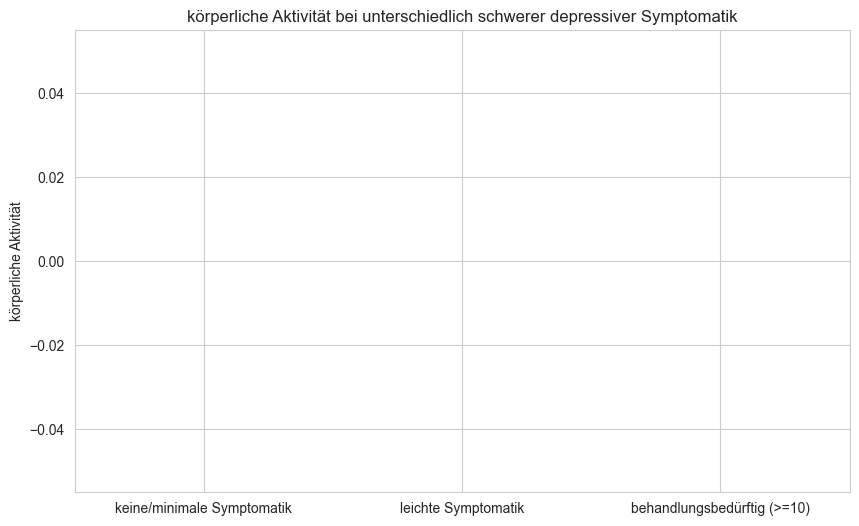

Durchschnitt keine/minimale Symptomatik: nan
Durchschnitt leichte Symptomatik: nan
Durchschnitt behandlungsbedürftig (>=10): nan


In [12]:
no_symtpoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['MEMPW']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['MEMPW']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['MEMPW']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \
                                                                'leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \
           showfliers = False)
plt.ylabel('körperliche Aktivität')
plt.title('körperliche Aktivität bei unterschiedlich schwerer depressiver Symptomatik')
plt.show()

print(f"Durchschnitt keine/minimale Symptomatik: {no_symtpoms.mean():.1f}")
print(f"Durchschnitt leichte Symptomatik: {mild_symptoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")



/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/2101358648.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symptoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \


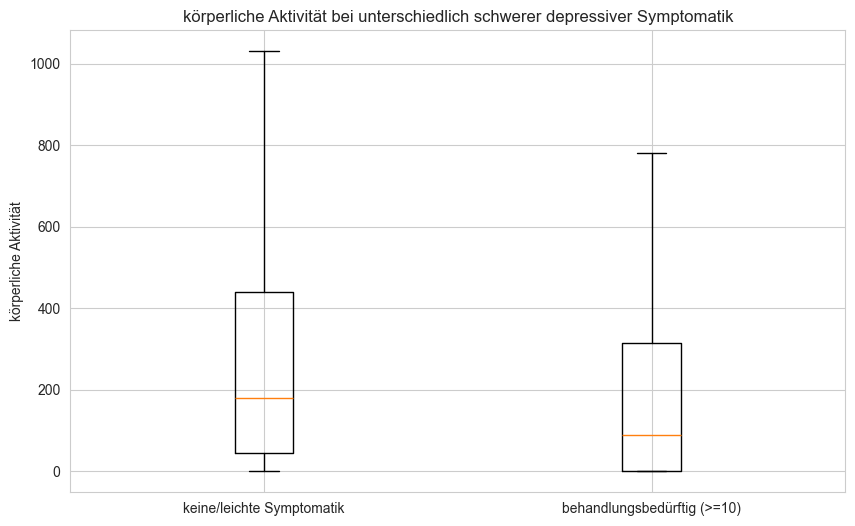

Durchschnitt keine/leichte Symptomatik: 378.8
Durchschnitt behandlungsbedürftig (>=10): 308.2


In [13]:
no_symptoms = df[df['DEPT'] == 0]['MEMPW']
should_treat = df[df['DEPT'] == 1]['MEMPW']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symptoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \
           showfliers = False)
plt.ylabel('körperliche Aktivität')
plt.title('körperliche Aktivität bei unterschiedlich schwerer depressiver Symptomatik')
plt.savefig('figures/Aktivität_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Durchschnitt keine/leichte Symptomatik: {no_symptoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")



/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/318978743.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


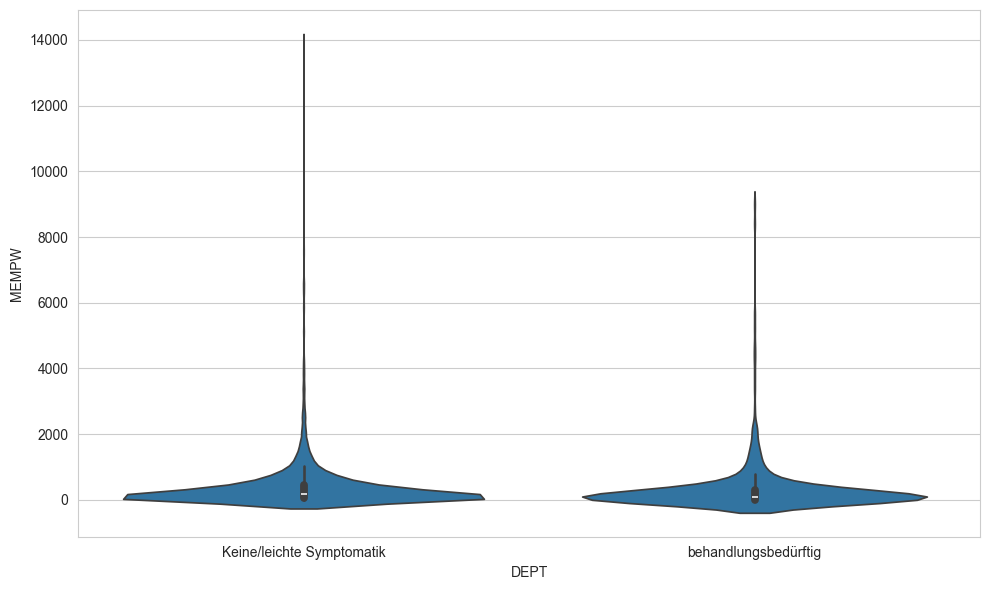

In [14]:
# Violin plot: combi --> Boxplot + KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x= 'DEPT' , y='MEMPW', ax=ax,  order=[
        0,
        1
    ])

ax.set_xticklabels([
    'Keine/leichte Symptomatik',
    'behandlungsbedürftig'
])
plt.tight_layout()
plt.show()

Körperliche Aktivität und depressive Symptomatik sind negativ korreliert.

/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/1661476192.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \


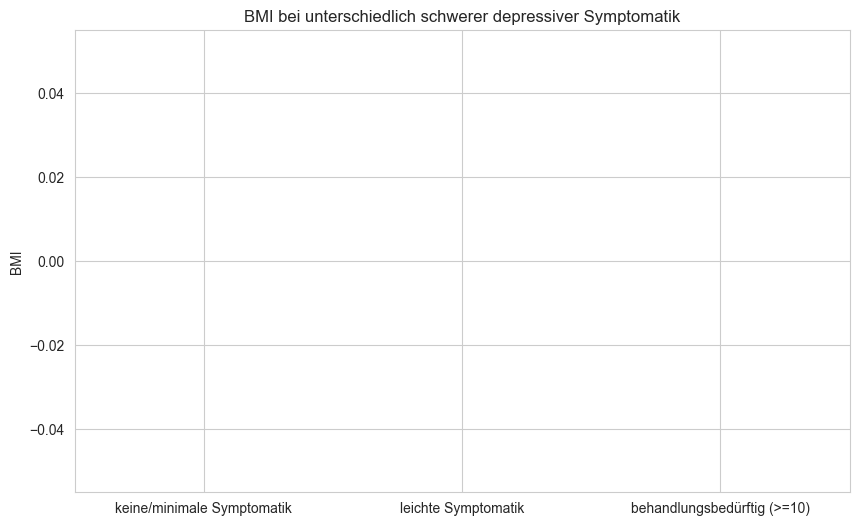

Durchschnitt keine/minimale Symptomatik: nan
Durchschnitt leichte Symptomatik: nan
Durchschnitt behandlungsbedürftig (>=10): nan


In [15]:
no_symtpoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['BMXBMI']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['BMXBMI']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['BMXBMI']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symtpoms, mild_symptoms, should_treat], labels=['keine/minimale Symptomatik', \
                                                                'leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \
           showfliers = False)
plt.ylabel('BMI')
plt.title('BMI bei unterschiedlich schwerer depressiver Symptomatik')
plt.show()

print(f"Durchschnitt keine/minimale Symptomatik: {no_symtpoms.mean():.1f}")
print(f"Durchschnitt leichte Symptomatik: {mild_symptoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")


/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/271962945.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_symtpoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \


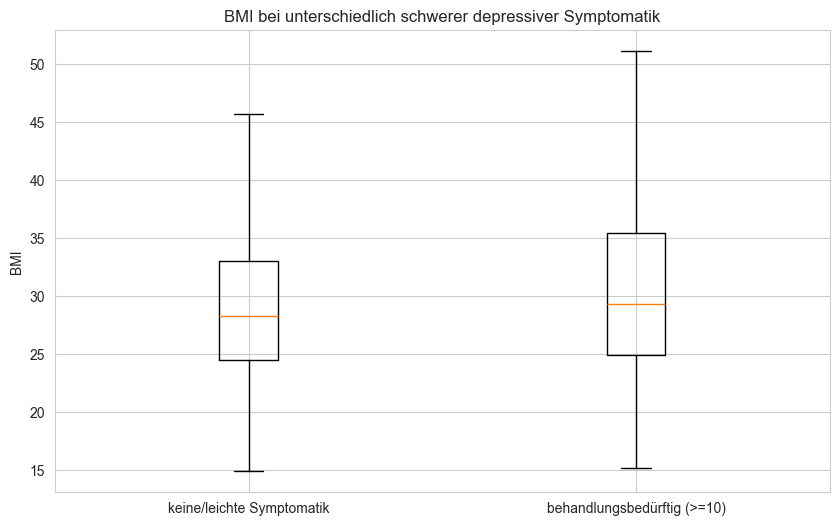

Durchschnitt keine/minimale Symptomatik: 29.4
Durchschnitt leichte Symptomatik: nan
Durchschnitt behandlungsbedürftig (>=10): 30.8


In [16]:
no_symtpoms = df[df['DEPT'] == 0]['BMXBMI']
should_treat = df[df['DEPT'] == 1]['BMXBMI']

plt.figure(figsize=(10, 6))
plt.boxplot([no_symtpoms, should_treat], labels=['keine/leichte Symptomatik', 'behandlungsbedürftig (>=10)'], \
           showfliers = False)
plt.ylabel('BMI')
plt.title('BMI bei unterschiedlich schwerer depressiver Symptomatik')
plt.show()

print(f"Durchschnitt keine/minimale Symptomatik: {no_symtpoms.mean():.1f}")
print(f"Durchschnitt leichte Symptomatik: {mild_symptoms.mean():.1f}")
print(f"Durchschnitt behandlungsbedürftig (>=10): {should_treat.mean():.1f}")


/var/folders/zf/_m40m0p955n9648y0htyy7dr0000gn/T/ipykernel_62199/3196113491.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


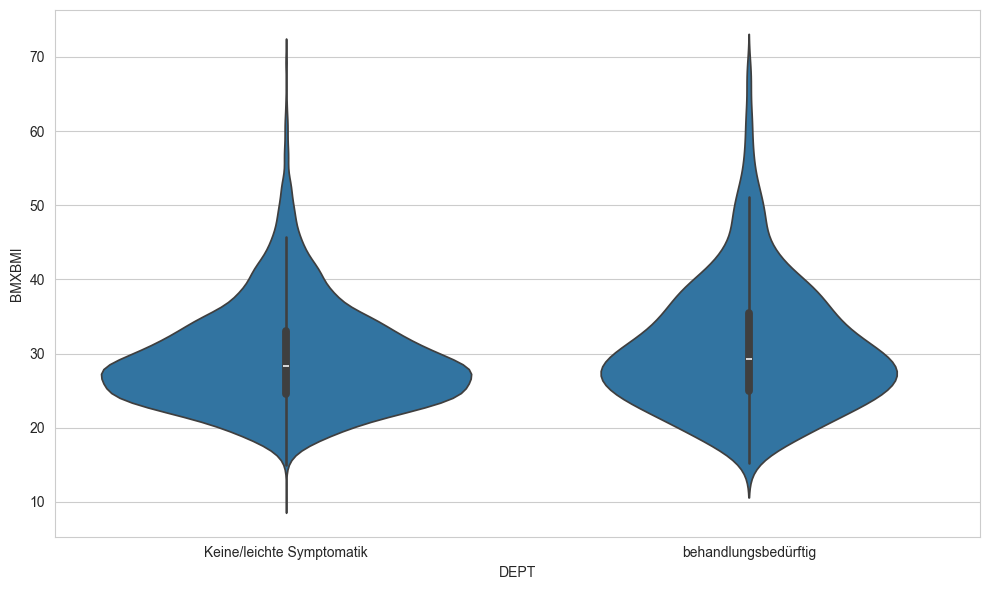

In [17]:
# Violin plot: combi --> Boxplot + KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x= 'DEPT' , y='BMXBMI', ax=ax,  order=[
        0,
        1
    ])

ax.set_xticklabels([
    'Keine/leichte Symptomatik',
    'behandlungsbedürftig'
])
plt.tight_layout()
plt.show()

In [18]:
df_copy = df.copy()
df_copy["DEPS"] = df_copy["DEPS"]

In [19]:
df_copy['BMI_Klasse'] = pd.cut(
    df_copy['BMXBMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Untergewicht', 'Normal', 'Übergewicht', 'Adipositas']
)

df_copy.groupby('BMI_Klasse')['DEPS'].mean()

BMI_Klasse
Untergewicht    0.720000
Normal          0.426081
Übergewicht     0.396324
Adipositas      0.533241
Name: DEPS, dtype: float64

In [20]:
bmi_dep = (
    df_copy
    .groupby('BMI_Klasse')['DEPS']
    .mean()
    .reset_index()
)

bmi_dep

,BMI_Klasse,DEPS
0,Untergewicht,0.720000
1,Normal,0.426081
2,Übergewicht,0.396324
3,Adipositas,0.533241


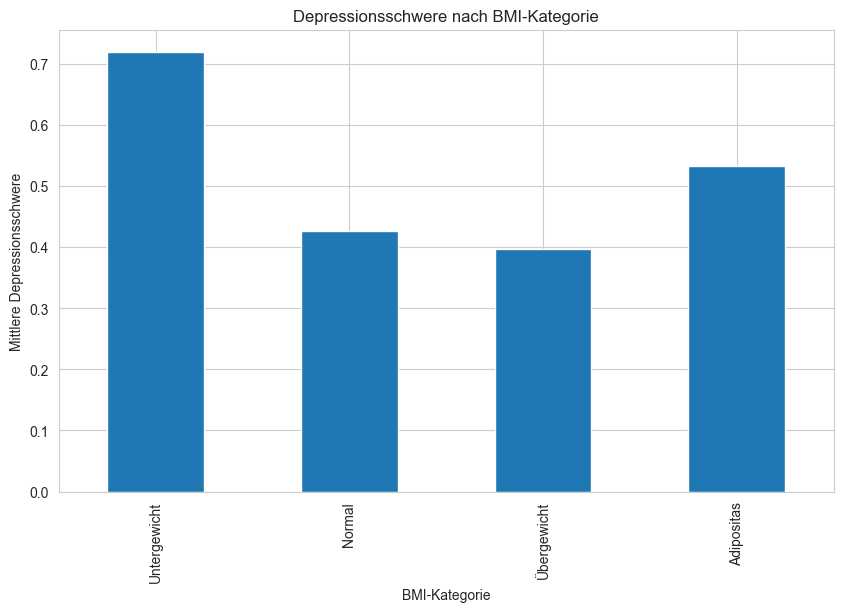

In [21]:
bmi_dep.plot(
    x='BMI_Klasse',
    y='DEPS',
    kind='bar',
    legend=False
)

plt.ylabel('Mittlere Depressionsschwere')
plt.xlabel('BMI-Kategorie')
plt.title('Depressionsschwere nach BMI-Kategorie')
plt.show()

In [22]:
pd.crosstab(
    df_copy['BMI_Klasse'],
    df_copy['DEPS'],
    normalize='index'
)

DEPS,0,1,2
BMI_Klasse,,,
Untergewicht,0.490000,0.300000,0.210000
Normal,0.688982,0.195955,0.115063
Übergewicht,0.719701,0.164273,0.116025
Adipositas,0.618652,0.229455,0.151893


Um die arbiträre Zuordnung der Depressionsschwere zu einer Ziffer zu umgehen, unterscheide ich nur noch zwischen "keine/leichte depressive Symptomatik" und "behandlungsbedürfite depressive Symptomatik". Der Mittelwert dieser binären Variable entspricht dem Anteil der Personen mit behandlungsbedürftiger Symptomatik.

In [24]:
#df_copy['DEPT'] = df_copy['DEPS'].replace({
   #  0 : 0,
  #   1 : 0,
 #    2 : 1
#})

In [25]:
bmi_dep = (
    df_copy
    .groupby('BMI_Klasse')['DEPT']
    .mean()
    .reset_index()
)

bmi_dep

,BMI_Klasse,DEPT
0,Untergewicht,0.210000
1,Normal,0.115063
2,Übergewicht,0.116025
3,Adipositas,0.151893


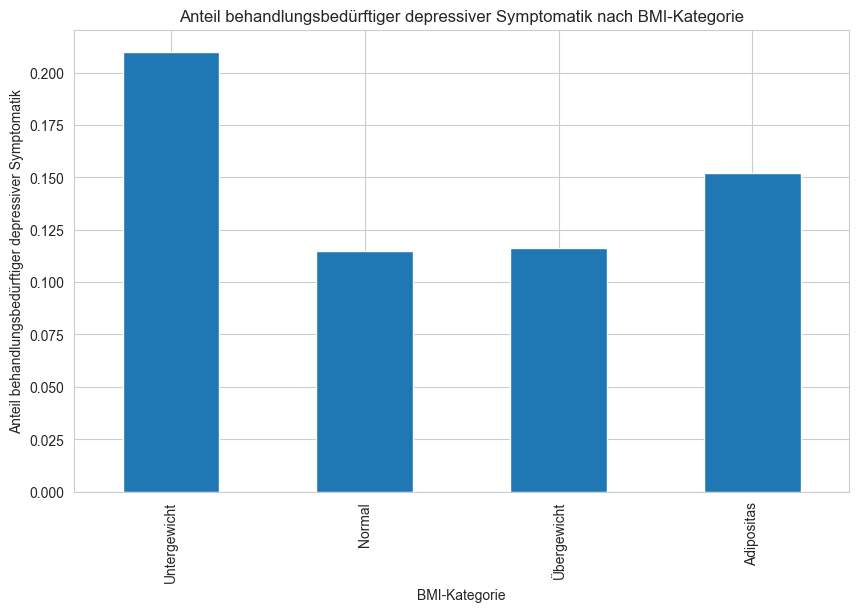

In [26]:
bmi_dep.plot(
    x='BMI_Klasse',
    y='DEPT',
    kind='bar',
    legend=False
)

plt.ylabel('Anteil behandlungsbedürftiger depressiver Symptomatik')
plt.xlabel('BMI-Kategorie')
plt.title('Anteil behandlungsbedürftiger depressiver Symptomatik nach BMI-Kategorie')
plt.savefig('figures/BMI_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

Ähnlich wie bei der Schlafdauer sind auch beim BMI Extremwerte mit stärkerer depressiver Symptomatik korrliert.  
Zwischen Normal- und Übergewicht gibt es kaum einen Unterschied.


In [ ]:
df_copy['Schlafdauer'] = pd.cut(
    df_copy['ASH'],
    bins=[0, 5, 10, 15],
    labels=['geringe Schlafdauer', 'normale Schlafdauer', 'hohe Schlafdauer']
)

df_copy.groupby('Schlafdauer')['DEPT'].mean()

In [ ]:
ash_dep = (
    df_copy
    .groupby('Schlafdauer')['DEPT']
    .mean()
    .reset_index()
)

ash_dep

In [ ]:
no_dep_ASH = df[df['DEPS'] == 'keine/minimale Symptomatik']['ASH']
mild_dep_ASH = df[df['DEPS'] == 'leichte Symptomatik']['ASH']
sev_dep_ASH = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['ASH']

plt.figure(figsize=(10, 6))
plt.hist(no_dep_ASH, bins=30, alpha=0.5, label='keine/minimale Symptomatik', color='green')
plt.hist(mild_dep_ASH, bins=30, alpha=0.5, label='leichte Symptomatik', color='yellow')
plt.hist(sev_dep_ASH, bins=30, alpha=0.5, label='behandlungsbedürftig (>=10)', color='red')
plt.xlabel('Average Sleep Hours')
plt.ylabel('Haeufigkeit')
plt.title('Averages Sleep Hours and Depression')
plt.legend()
plt.show()

In [ ]:
no_dep_ASH = df[df['DEPS'] == 'keine/minimale Symptomatik']['BMXBMI']
mild_dep_ASH = df[df['DEPS'] == 'leichte Symptomatik']['BMXBMI']
sev_dep_ASH = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['BMXBMI']

plt.figure(figsize=(10, 6))
plt.hist(no_dep_ASH, bins=30, alpha=0.5, label='keine/minimale Symptomatik', color='green')
plt.hist(mild_dep_ASH, bins=30, alpha=0.5, label='leichte Symptomatik', color='yellow')
plt.hist(sev_dep_ASH, bins=30, alpha=0.5, label='behandlungsbedürftig (>=10)', color='red')
plt.xlabel('BMI')
plt.ylabel('Haeufigkeit')
plt.title('BMI and Depression')
plt.legend()
plt.show()

In [ ]:
cross = pd.crosstab(df['RIAGENDR'], df['DEPS'])
cross.columns = ['keine/minimale Symptomatik', 'leichte Symptomatik', 'behandlungsbedürftig (>=10)']
cross.index = ['männlich', 'weiblich']

cross.plot(kind='bar', figsize=(10, 6), color=['green', 'yellow', 'red'])
plt.xlabel('Geschlecht')
plt.ylabel('Anzahl')
plt.title('Schwere depressiver Symptomatik nach Geschlecht')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print(cross)

In [ ]:
gend_dep = (
    df_copy
    .groupby('RIAGENDR')['DEPT']
    .mean()
    .reset_index()
)

gend_dep

In [ ]:
ax = gend_dep.plot(
    x='RIAGENDR',
    y='DEPT',
    kind='bar',
    legend=False
)

plt.ylabel('Mittlere Depressionsschwere')
plt.xlabel('Geschlecht')
plt.title('Anteil an behandlungsbedürftiger depressiver Symptomatik nach Geschlecht')
ax.set_xticklabels(['männlich', 'weiblich'])
plt.savefig('figures/Geschlecht_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

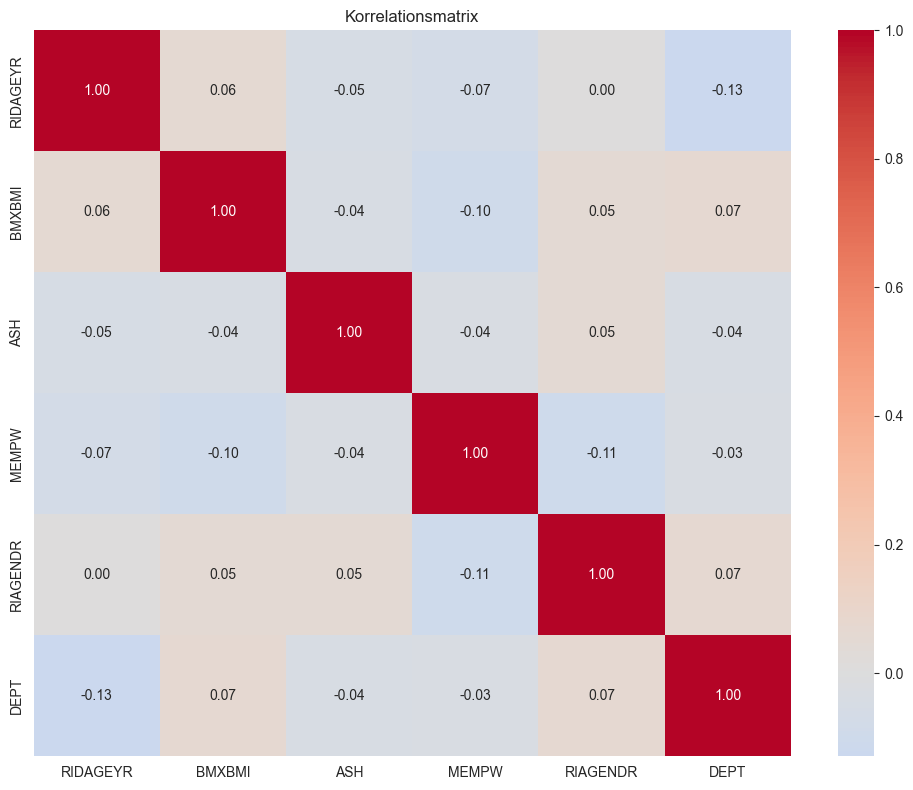

Korrelation mit condition:
DEPT        1.000000
RIAGENDR    0.072886
BMXBMI      0.065185
MEMPW      -0.033686
ASH        -0.043380
RIDAGEYR   -0.129436
Name: DEPT, dtype: float64


In [34]:
cols = ['RIDAGEYR', 'BMXBMI', 'ASH', 'MEMPW', 'RIAGENDR', 'DEPT']
corr = df_copy[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korrelationsmatrix')
plt.tight_layout()
plt.savefig('figures/Korrelationsmatrix.png', dpi = 300, bbox_inches= 'tight')
plt.show()

print("Korrelation mit condition:")
print(corr['DEPT'].sort_values(ascending=False))

ASH und BMXBMI sind deshalb weniger stark mit DEPT korreliert als man annehmen könnte, weil Abweichungen vom Mittelwert in beide Richtungen mit der schwere der depressiven Symptomatik korreliert sind. Im MIttel verschwindet die Korrelation also wieder.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

colors = [
    'green' if d == 0
    else 'yellow' if d == 1
    else 'red'
    for d in df_copy['DEPS']
]

ax[0].scatter(df_copy['RIDAGEYR'], df_copy['BMXBMI'], c=colors, alpha=0.5)
ax[0].set_xlabel('Alter')
ax[0].set_ylabel('BMI')
ax[0].set_title('Alter vs BMI')

ax[1].scatter(df_copy['RIDAGEYR'], df['ASH'], c=colors, alpha=0.5)
ax[1].set_xlabel('Alter')
ax[1].set_ylabel('Schlafdauer')
ax[1].set_title('Alter vs Schladfauer')

plt.tight_layout()
plt.show()

In [ ]:
mean_dep = df_copy['DEPT'].mean()

print(mean_dep)

In [ ]:
df_copy['DMDMARTZ'] = df_copy['DMDMARTZ'].map({
    1: 'Married/Living with partner',
    2: 'Widowed/Divorced/Separated',
    3: 'Never married',
    99: 'No answer'
})

In [ ]:
counts = df_copy['DMDMARTZ'].value_counts()

fig, ax = plt.subplots(figsize=(12, 10))

ax.bar(counts.index, counts.values)
ax.set_title('Häufigkeit der Marital-Status-Kategorien')
ax.set_ylabel('Anzahl')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
martz_dep = (
    df_copy
    .groupby('DMDMARTZ')['DEPT']
    .mean()
)

martz_dep

In [ ]:
order = [
    "Married/Living with partner",
    "Widowed/Divorced/Separated",
    "Never married",
    "No answer"
]

plt.bar(order, martz_dep.reindex(order).values)

plt.ylabel("Anteil behandlungsbedürftiger depressiver Symptomatik")
plt.xlabel("Familienstand")
plt.title("Anteil behandlungsbedürftiger depressiver Symptomatik nach Familienstand")
plt.savefig('figures/Familienstand_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

Leben mit einem Partner ist eindeutig mit milderer Symptomatik korrliert. Interessanterweise sind selbst verwitwete/geschiedene/getrennte Probenden weniger depressiv als nie verheiratete.  
Wir wissen nicht ob die Probanden die keine Antwort gegeben haben sich gleichmäßig auf die anderen Kategorien verteilen würden. Allerdings ist der Anzahl an 'No answer' so gering, dass das Gesamtergebnis dadurch nicht stark verfälscht worden sein dürfte.

In [ ]:
df_copy['DMDEDUC2'] = df_copy['DMDEDUC2'].map({
    1: 'Less than 9th grade',
    2: '9-11th grade (Includes 12th grade with no diploma)',
    3: 'High school graduate/GED or equivalent',
    4: 'Some college or AA degree', 
    5: 'College graduate or above',
    9: 'No Answer'
})


In [ ]:
counts = df_copy['DMDEDUC2'].value_counts()

fig, ax = plt.subplots(figsize=(12, 10))

ax.bar(counts.index, counts.values)
ax.set_title('Häufigkeit der Ausbildungs-Kategorien')
ax.set_ylabel('Anzahl')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
educ_dep = (
    df_copy
    .groupby('DMDEDUC2')['DEPT']
    .mean()
)

educ_dep

In [ ]:
order = [
    "Less than 9th grade",
    "9-11th grade (Includes 12th grade with no diploma)",
    "High school graduate/GED or equivalent",
    "College graduate or above",
    "No Answer"
]

plt.bar(order, educ_dep.reindex(order).values)

plt.ylabel('Anteil von Probanden mit behandlungsbedürftiger depressiver Symptomatik')
plt.xlabel('Bildungsgrad')
plt.title('Anteil von Probanden mit behandlungsbedürftiger depressiver Symptomatik nach Ausbildungstyp')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/Bildungsgrad_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

möglicherweise sind die Ausbilungskategorien "less than 9th grade" und "9-11th grade" aufgrund der geringeren Probandenzahl eher vorsichtig zu bewerten.

Ein höherer Bildungsstatus mit geringerer depressiver Symptomatik korreliert.

In [ ]:
df_copy['OCD150'] = df_copy['OCD150'].map({
    1: 'Working at a job or business',  
    2: 'With a job or business but not at work',
    3: 'Looking for work',
    4: 'Not working at a job or business',
    9: 'No Answer'
})

In [ ]:
counts = df_copy['OCD150'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(counts.index, counts.values)
ax.set_title('Häufigkeit der verschiedenen Job-Situationen')
ax.set_ylabel('Anzahl')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
oc_dep = (
    df_copy
    .groupby('OCD150')['DEPT']
    .mean()
)

oc_dep

In [ ]:
order = [
    'Working at a job or business',  
    'With a job or business but not at work',
    'Looking for work',
    'Not working at a job or business',
    'No Answer'
]

plt.bar(order, oc_dep.reindex(order).values)

plt.ylabel('Anteil von Probanden mit behandlungsbedürftiger depressiver Symptomatik')
plt.xlabel('Beschäftigung')
plt.title('Anteil von Probanden mit behandlungsbedürftiger depressiver Symptomatik nach Beschäftigung')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/Beschäftigung_dep_Sympt.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_pp = df[['RIDAGEYR', 'BMXBMI',
            'ASH', 'MEMPW', 'DEPS']]
p = sns.pairplot(df_pp, hue='DEPS', palette={
        'keine/minimale Symptomatik': 'green',
        'leichte Symptomatik': 'yellow',
        'behandlungsbedürftig (>=10)': 'red'
    })
p.figure.suptitle(
    'Zusammenhang von Alter, BMI, Schlafdauer und körperlicher Aktivität\nnach depressiver Symptomatik',
    y = 1.02
)
plt.show()

In [ ]:
df_pp = df_copy[['RIDAGEYR', 'BMXBMI', 'ASH', 'MEMPW', 'DEPT']].copy()

df_pp['Depressionsstatus'] = df_pp['DEPT'].map({
    0: 'keine/leichte Symptomatik',
    1: 'behandlungsbedürftige Symptomatik'
})

p = sns.pairplot(
    df_pp,
    vars=['RIDAGEYR', 'BMXBMI', 'ASH', 'MEMPW'],
    hue='Depressionsstatus',
    palette={
        'keine/leichte Symptomatik': 'green',
        'behandlungsbedürftige Symptomatik': 'red'
    }
)

p.figure.suptitle(
    'Zusammenhang von Alter, BMI, Schlafdauer und körperlicher Aktivität\nnach depressiver Symptomatik',
    y = 1.02
)
plt.show()

In [28]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [29]:
import plotly.express as px

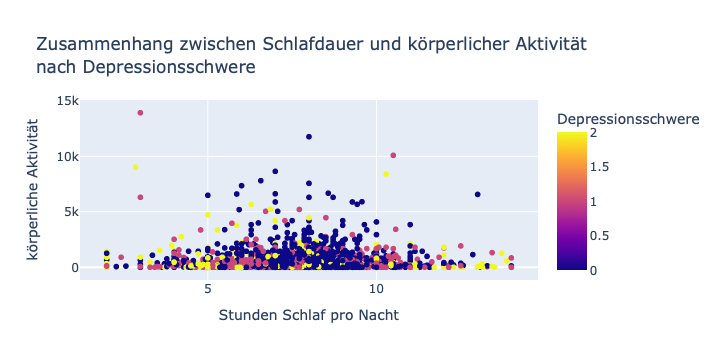

In [30]:
# Interactive scatter with color
fig = px.scatter(df, x='ASH', y='MEMPW', color='DEPS',
                 hover_data=['DEPS', 'BMXBMI'], color_discrete_map={
        'keine/minimale Symptomatik': 'green',
        'leichte Symptomatik': 'yellow',
        'behandlungsbedürftig (>=10)': 'red'
    },
    labels={
        'ASH': 'Stunden Schlaf pro Nacht',
        'MEMPW': 'körperliche Aktivität',
        'DEPS': 'Depressionsschwere',
        'BMXBMI': 'BMI'
    }, title = 'Zusammenhang zwischen Schlafdauer und körperlicher Aktivität <br>nach Depressionsschwere'
)

fig.show()

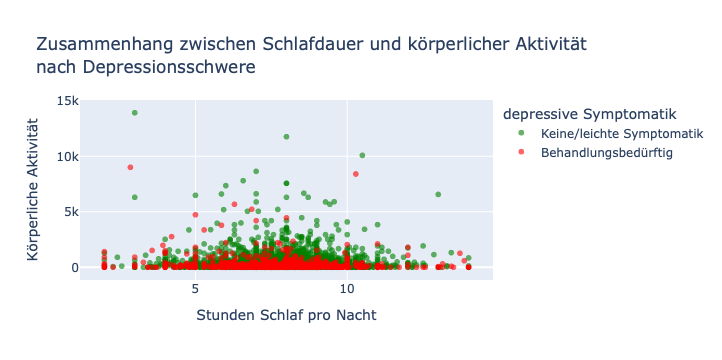

In [31]:
df['depressive Symptomatik'] = df['DEPT'].astype(str).map({
'0': 'Keine/leichte Symptomatik',
'1': 'Behandlungsbedürftig'
})
fig = px.scatter(
df,
x='ASH',
y='MEMPW',
color='depressive Symptomatik',
hover_data=['DEPT', 'BMXBMI'],
color_discrete_map={
'Keine/leichte Symptomatik': 'green',
'Behandlungsbedürftig': 'red'
}, opacity=0.6,
labels={
'ASH': 'Stunden Schlaf pro Nacht',
'MEMPW': 'Körperliche Aktivität',
'DEPT': 'Depressionsschwere',
'BMXBMI': 'BMI'
},
title='Zusammenhang zwischen Schlafdauer und körperlicher Aktivität<br>nach Depressionsschwere'
)
fig.write_image('figures/Schlaf_Aktivität_Dep.png')
fig.write_html('figures/Schlaf_Aktivität_Dep.html') 
fig.show()


In [ ]:
# Interactive scatter with color
fig = px.scatter(df_copy, x='ASH', y='MEMPW', color='BMI_Klasse',
                 hover_data=['DEPS', 'BMXBMI'], color_discrete_map = {
                     'Untergewicht' : 'purple',
                     'Normal' : 'green',
                     'Übergewicht' : 'yellow',
                     'Adipositas': 'red'
                },
                labels={
                    'ASH': 'Stunden Schlaf pro Nacht',
                    'MEMPW': 'körperliche Aktivität',
                    'DEPS': 'Depressionsschwere',
                    'BMXBMI': 'BMI'
                }, title = 'Zusammenhang zwischen Schlafdauer und körperlicher Aktivität <br>nach BMI-Klasse'
)
fig.show()

## Zusammenfassung

In [ ]:
print("Erkenntnisse Depression Screening NHANES")
print("="*50)

anteil_beh = df_copy['DEPT'].mean()
print(f"Anteil an Probanden mit behandlungsbedürftiger depressiver Symptomatik: {anteil_beh:.2f}")

anteil_m=df_copy[df_copy['RIAGENDR']==1]['DEPT'].mean()
anteil_f=df_copy[df_copy['RIAGENDR']==2]['DEPT'].mean()
print(f"Anteil an männlichen Probanden mit behandlungsbedürftiger depressiver Symptomatik: {anteil_m:.2f}")
print(f"Anteil an weiblichen Probanden mit behandlungsbedürftiger depressiver Symptomatik: {anteil_f:.2f}")

In [ ]:
no_symtpoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['RIDAGEYR']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['RIDAGEYR']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['RIDAGEYR']

print(f"Durchschnittsalter bei keiner/minimaler Symptomatik: {no_symtpoms.mean():.1f}")
print(f"Durchschnittsalter bei leichter Symptomatik: {mild_symptoms.mean():.1f}")
print(f"Durchschnittsalter bei behandlungsbedürftiger Symptomatik: {should_treat.mean():.1f}")

In [ ]:
for _, row in bmi_dep.iterrows():
    print(
        f"Anteil behandlungsbedürftiger Depression in der Gewichtsklasse "
        f"{row['BMI_Klasse']}: {row['DEPT']:.1%}"
    )

In [ ]:
for _, row in ash_dep.iterrows():
    print(
        f"Anteil behandlungsbedürftiger Depression bei: "
        f"{row['Schlafdauer']}: {row['DEPT']:.1%}"
    )

>Sowohl beim BMI als auch bei der Anzahl der durschnittlich geschlafenen Stunden gibt es eine Häufung depressiver Symptomatik bei den Extremwerten.

In [ ]:
no_symtpoms = df[df['DEPS'] == 'keine/minimale Symptomatik']['MEMPW']
mild_symptoms = df[df['DEPS'] == 'leichte Symptomatik']['MEMPW']
should_treat = df[df['DEPS'] == 'behandlungsbedürftig (>=10)']['MEMPW']

print("Durchschnittliche wöchentliche Minutenzahl mittlere körperlicher Aktivität bei:")
print(f"keiner/minimaler Symptomatik: {no_symtpoms.mean():.1f}")
print(f"leichter Symptomatik: {mild_symptoms.mean():.1f}")
print(f"behandlungsbedürftiger Symptomatik): {should_treat.mean():.1f}")



>Stärkere depressive Symptmatik ist mit etwas weniger körperlicher Aktivität korreliert.

In [ ]:
order = [
    "Less than 9th grade",
    "9-11th grade (Includes 12th grade with no diploma)",
    "High school graduate/GED or equivalent",
    "College graduate or above",
    "No Answer"
]

for educ, dep in educ_dep.reindex(order).items():
    print(
        f"Anteil behandlungsbedürftiger Depression bei {educ}: {dep:.1%}"
    )

>Bei steigendem Bildungsniveau sinkt die Wahrcheinlichkeit des Auftretens einer behandlungsbedürftigen depressiven Symtpomatik.

In [ ]:
order = [
    'Working at a job or business',  
    'With a job or business but not at work',
    'Looking for work',
    'Not working at a job or business',
    'No Answer'
]

for oc, dep in oc_dep.reindex(order).items():
    print(
        f"Anteil behandlungsbedürftiger Depression bei {oc}: {dep:.1%}"
    )

>Probanden ohne Arbeit - insbesondere Probanden, die Arbeit suchen - haben eine höhere Wahrscheinlichkeit eine behandlungsbedürftiger depressive Symptomatik anzugeben.

In [ ]:
order = [
    "Married/Living with partner",
    "Widowed/Divorced/Separated",
    "Never married",
    "No answer"
]
for ma, dep in martz_dep.reindex(order).items():
    print(
        f"Anteil behandlungsbedürftiger Depression - {ma}: {dep:.1%}"
    )

>Verheiratete/verpartnerte Personen haben eine geringere Wahrscheinlichkeit eine behandlungsbedürftiger depressive Symptomatik anzugeben. Selbst nach Trennung ist die Wahrscheinlichkeit noch geringer, als bei Probanden, die nie verheiratet waren. 